# Wiremind Technical Test - Exploratory Data Analysis

**Objective**: Analyze train demand dataset to understand patterns, distributions, and correlations that will inform model architecture choices.

**Goal**: Predict unconstrained demand given price, days before departure (sale_day_x), and contextual features.

---

## Table of Contents
1. [Data Loading & Basic Info](#1-data-loading)
2. [Data Quality & Missing Values](#2-data-quality)
3. [Target Variable Analysis (Demand)](#3-target-analysis)
4. [Feature Distributions](#4-feature-distributions)
5. [Correlation Analysis & Feature Selection](#5-correlation)
6. [Temporal Patterns](#6-temporal)
7. [Route Analysis (OD Level)](#7-route-analysis)
8. [Competition Analysis](#8-competition)
9. [Outlier Detection](#9-outliers)
10. [Summary & Modeling Implications](#10-summary)

---
## 1. Data Loading & Basic Info <a id='1-data-loading'></a>

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load datasets
trainset = pd.read_parquet("cayzn_train.parquet")
testset = pd.read_parquet("cayzn_test.parquet")

# Display dataset dimensions
print(f"Train dataset shape: {trainset.shape}")
print(f"Test dataset shape: {testset.shape}")
print(f"\nTrain/Test ratio: {trainset.shape[0] / testset.shape[0]:.1f}:1")

# Show all features and their data types
print("\n=== Feature Types ===")
features = trainset.columns.to_list()
types = trainset.dtypes
for feature, dtype in zip(features, types): 
    print(f"{feature:40s}: {dtype}")

Train dataset shape: (632841, 30)
Test dataset shape: (32565, 30)

Train/Test ratio: 19.4:1

=== Feature Types ===
demand                                  : int64
departure_date                          : str
destination_current_public_holiday      : int64
destination_current_school_holiday      : int64
destination_days_to_next_public_holiday : int64
destination_days_to_next_school_holiday : int64
destination_station_name                : str
od_destination_time                     : int64
od_number_of_similar_12_hours           : int64
od_number_of_similar_2_hours            : int64
od_number_of_similar_4_hours            : int64
od_origin_month                         : int64
od_origin_time                          : int64
od_origin_week                          : int64
od_origin_weekday                       : int64
od_origin_year                          : int64
od_travel_time_minutes                  : int64
origin_current_public_holiday           : int64
origin_current_school_hol

**Observations:**
- **632,841 training samples** across **30 features**
- **32,565 test samples** (≈5% of train set)
- Mix of numerical (26) and string (4) features
- String features: dates (departure_date, sale_date) and stations (origin/destination)

In [3]:
# Examine categorical features: stations
print("=== Destination Stations ===")
print(trainset["destination_station_name"].value_counts())
print(f"\nNumber of unique destinations: {trainset['destination_station_name'].nunique()}")
print(f"Number of unique origins: {trainset['origin_station_name'].nunique()}")

=== Destination Stations ===
destination_station_name
bb     260429
cgm    124103
cpe     97867
rb      60705
ag      59702
cdm     30035
Name: count, dtype: int64

Number of unique destinations: 6
Number of unique origins: 6


**Observations:**
- **6 stations** serve as both origins and destinations
- Station **'bb'** is the most frequent destination (260,429 records)
- **Encoding strategy**: Can use one-hot encoding (only 6 categories) 

### Key Feature Definitions

Understanding critical features:

- **sale_day_x**: Days remaining before departure (e.g., -2 means 2 days before departure)
- **sale_date**: Date when ticket was sold = `departure_date + sale_day_x`
- **price**: Offered ticket price for this sale_day_x
- **demand**: <span style="color:orange">(TARGET)</span>  - Unconstrained demand observed at this price and sale_day_x
- **od_origin_time**: Departure time encoded as `(hour × 60) + minutes` (e.g., 16:08 → 968)
- **od_travel_time_minutes**: Journey duration in minutes

In [4]:
# Display first few rows to understand data structure
trainset.head()

,demand,departure_date,destination_current_public_holiday,destination_current_school_holiday,destination_days_to_next_public_holiday,destination_days_to_next_school_holiday,destination_station_name,od_destination_time,od_number_of_similar_12_hours,od_number_of_similar_2_hours,...,origin_days_to_next_school_holiday,origin_station_name,price,sale_date,sale_day,sale_day_x,sale_month,sale_week,sale_weekday,sale_year
0,1,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-02,2,-89,12,6,6,2018
1,6,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-03,3,-88,12,0,0,2018
2,5,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-04,4,-87,12,1,1,2018
3,0,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-05,5,-86,12,2,2,2018
4,0,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-06,6,-85,12,3,3,2018


---
## 2. Data Quality & Missing Values <a id='2-data-quality'></a>

In [5]:
# Convert date strings to datetime for temporal analysis
trainset["departure_date"] = pd.to_datetime(trainset["departure_date"])
trainset["sale_date"] = pd.to_datetime(trainset["sale_date"])

# Analyze date ranges
print("=== Departure Date Range ===")
print(trainset["departure_date"].describe())
print("\n=== Sale Date Range ===")
print(trainset["sale_date"].describe())

=== Departure Date Range ===
count                        632841
mean     2020-01-17 00:20:08.538638
min             2019-03-01 00:00:00
25%             2019-07-26 00:00:00
50%             2020-02-05 00:00:00
75%             2020-08-08 00:00:00
max             2020-10-15 00:00:00
Name: departure_date, dtype: object

=== Sale Date Range ===
count                        632841
mean     2019-12-04 20:27:05.970504
min             2018-12-02 00:00:00
25%             2019-06-10 00:00:00
50%             2019-12-03 00:00:00
75%             2020-06-22 00:00:00
max             2020-10-14 00:00:00
Name: sale_date, dtype: object


**Observations:**
- **Departure dates**: March 2019 to October 2020 (~19 months)
- **Sale dates**: December 2018 to October 2020 (starts earlier due to advance bookings)
- Data spans **pre-COVID and COVID periods** (2020) - potential distribution shift to consider

In [6]:
# Check for missing values (NaN)
missing_count = trainset.isna().sum().sum()
print(f"Total missing values (NaN): {missing_count}")

if missing_count == 0:
    print("✓ No explicit missing values detected!")

Total missing values (NaN): 0
✓ No explicit missing values detected!


In [7]:
# Check for implicit missing values (coded as -1 in competition features)
print("=== Special Values Check (e.g., -1 for missing) ===")
similar_cols = [col for col in trainset.columns if 'similar' in col.lower()]

for col in similar_cols:
    neg_count = (trainset[col] == -1).sum()
    if neg_count > 0:
        print(f"{col:40s}: {neg_count:5,} rows (-1) = {neg_count/len(trainset)*100:.2f}%")

print("\nDecision: Very few rows (<0.02%) have -1 values.")
print("Options: (1) Drop these rows, (2) Impute with median, or (3) Keep as separate category.")

=== Special Values Check (e.g., -1 for missing) ===
od_number_of_similar_12_hours           :    44 rows (-1) = 0.01%
od_number_of_similar_2_hours            :   100 rows (-1) = 0.02%
od_number_of_similar_4_hours            :    44 rows (-1) = 0.01%

Decision: Very few rows (<0.02%) have -1 values.
Options: (1) Drop these rows, (2) Impute with median, or (3) Keep as separate category.


**Data Quality Summary:**
- ✓ **No missing values** (NaN)
- ✓ **Minimal special values** (<0.02% with -1 in competition features)
- ✓ **Clean dataset** - ready for analysis

---
## 3. Target Variable Analysis (Demand) <a id='3-target-analysis'></a>

Understanding the distribution of our target is **critical** for model selection.

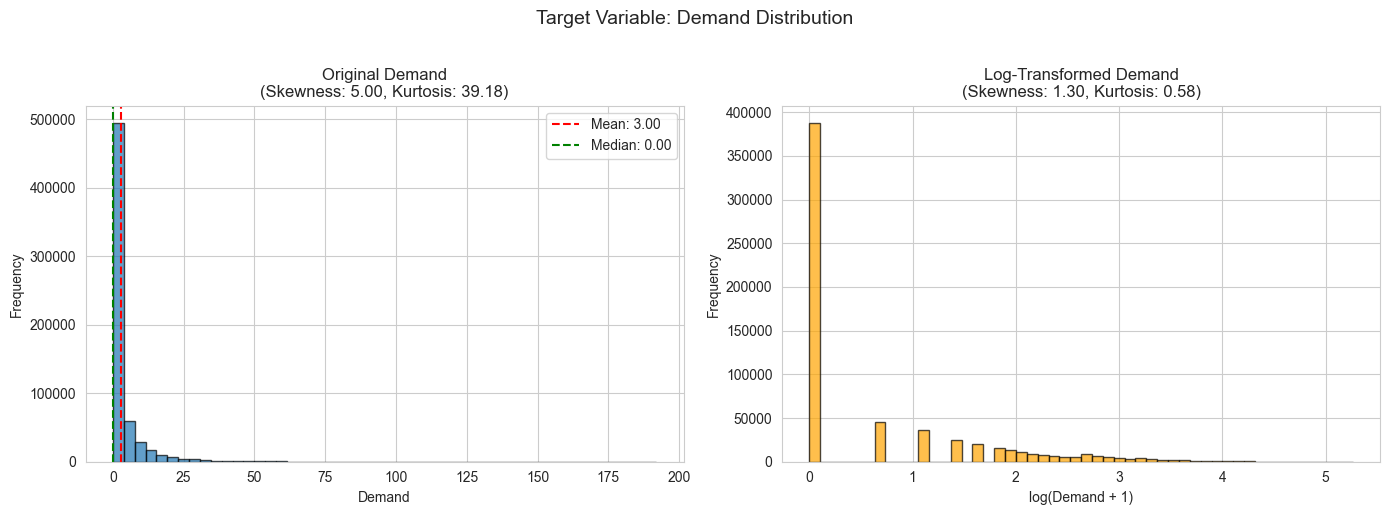

=== Demand Statistics (Original) ===
Mean:   3.000
Median: 0.000
Std:    7.257
Min:    0
Max:    192

=== Demand Statistics (Log-Transformed) ===
Mean:   0.684
Median: 0.000
Std:    1.009


In [8]:
# Visualize demand distribution (original vs log-transformed)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
skewness = trainset["demand"].skew()
kurtosis = trainset["demand"].kurtosis()
ax1.hist(trainset["demand"], bins=50, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Demand")
ax1.set_ylabel("Frequency")
ax1.set_title(f"Original Demand\n(Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f})")
ax1.axvline(trainset["demand"].mean(), color='red', linestyle='--', label=f'Mean: {trainset["demand"].mean():.2f}')
ax1.axvline(trainset["demand"].median(), color='green', linestyle='--', label=f'Median: {trainset["demand"].median():.2f}')
ax1.legend()

# Log-transformed distribution
skewness_log = np.log1p(trainset["demand"]).skew()
kurtosis_log = np.log1p(trainset["demand"]).kurtosis()
ax2.hist(np.log1p(trainset["demand"]), bins=50, edgecolor="black", alpha=0.7, color='orange')
ax2.set_xlabel("log(Demand + 1)")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Log-Transformed Demand\n(Skewness: {skewness_log:.2f}, Kurtosis: {kurtosis_log:.2f})")

fig.suptitle("Target Variable: Demand Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print statistics
print("=== Demand Statistics (Original) ===")
print(f"Mean:   {trainset['demand'].mean():.3f}")
print(f"Median: {trainset['demand'].median():.3f}")
print(f"Std:    {trainset['demand'].std():.3f}")
print(f"Min:    {trainset['demand'].min()}")
print(f"Max:    {trainset['demand'].max()}")

print("\n=== Demand Statistics (Log-Transformed) ===")
print(f"Mean:   {np.log1p(trainset['demand']).mean():.3f}")
print(f"Median: {np.log1p(trainset['demand']).median():.3f}")
print(f"Std:    {np.log1p(trainset['demand']).std():.3f}")

In [9]:
# Analyze zero-demand frequency (critical insight!)
zero_demand_count = (trainset['demand'] == 0).sum()
zero_demand_pct = zero_demand_count / len(trainset) * 100

print(f"\n️CRITICAL FINDING: Zero Demand")
print(f"Zero demand occurrences: {zero_demand_count:,} ({zero_demand_pct:.2f}%)")
print(f"Non-zero demand: {len(trainset) - zero_demand_count:,} ({100 - zero_demand_pct:.2f}%)")


️CRITICAL FINDING: Zero Demand
Zero demand occurrences: 387,961 (61.30%)
Non-zero demand: 244,880 (38.70%)


### 🔴 Critical Insights: Demand Distribution

1. **Highly Right-Skewed** (skewness = 5.0)
   - Long tail with few very high demand values
   - Mean (3.0) >> Median (0.0)

2. **Zero-Inflated** (61.3% zeros!)
   - Majority of observations have zero demand
   - This is **NOT** a typical regression problem

3. **Log Transformation Helps** (skewness drops to 1.3)
   - More symmetric distribution
   - But doesn't solve zero-inflation problem

### 💡 Modeling Implications:

**Option 1: Two-Stage Model** 
- Stage 1: Binary classifier for P(demand > 0)
- Stage 2: Regression for E[demand | demand > 0]

**Option 2: Zero-Inflated Models**
- Zero-Inflated Poisson (ZIP) or Negative Binomial (ZINB)

**Option 3: Tree-Based Models**
- XGBoost/LightGBM naturally handle skewed distributions
- Use Tweedie loss or custom objective

**Target Transformation:**
- Use `log(demand + 1)` as target if using regression
- Exponentiate predictions: `demand_pred = exp(y_pred) - 1`

---
## 4. Feature Distributions <a id='4-feature-distributions'></a>

### 4.1 Price Distribution

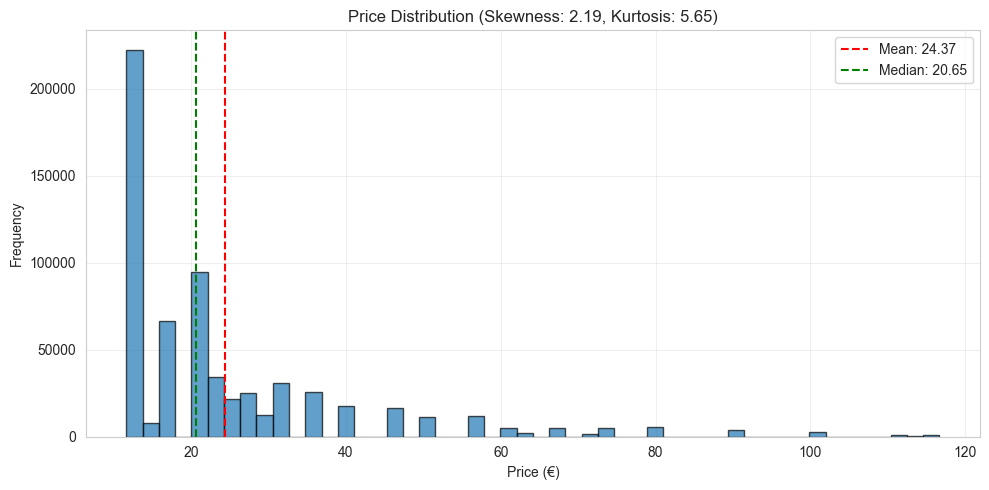

Mean:   24.37 €
Median: 20.65 €
Std:    16.87 €
Range:  [11.65, 116.65] €


In [10]:
# Analyze price distribution
skewness = trainset["price"].skew() 
kurtosis = trainset["price"].kurtosis()

plt.figure(figsize=(10, 5))
plt.hist(trainset["price"], bins=50, edgecolor="black", alpha=0.7)
plt.axvline(trainset["price"].mean(), color='red', linestyle='--', 
            label=f'Mean: {trainset["price"].mean():.2f}')
plt.axvline(trainset["price"].median(), color='green', linestyle='--', 
            label=f'Median: {trainset["price"].median():.2f}')
plt.xlabel("Price (€)")
plt.ylabel("Frequency")
plt.title(f"Price Distribution (Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean:   {trainset['price'].mean():.2f} €")
print(f"Median: {trainset['price'].median():.2f} €")
print(f"Std:    {trainset['price'].std():.2f} €")
print(f"Range:  [{trainset['price'].min():.2f}, {trainset['price'].max():.2f}] €")

**Observations:**
- **Right-skewed** but less than demand (skewness = 2.2)
- **Bimodal distribution** - two price clusters:
  - Low-price cluster around 11-20€ (likely budget routes)
  - Mid-price cluster around 20-40€ (standard routes)
- Few high-price outliers (>100€)
- **Price range**: 11.65€ to 116.65€

### 4.2 Price vs Demand Relationship

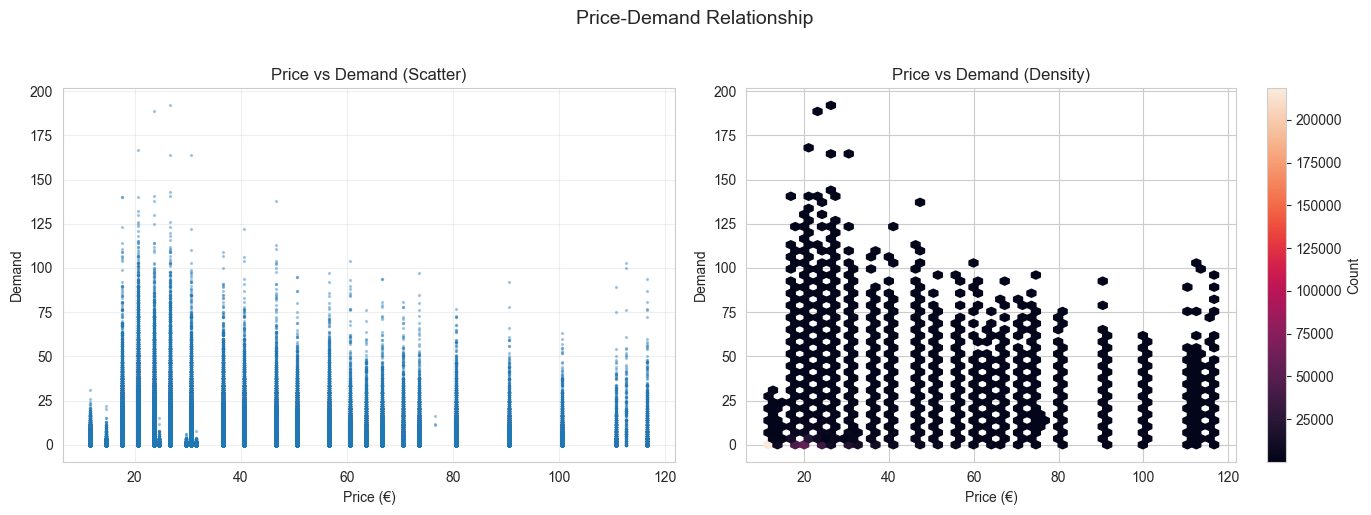

In [11]:
# Visualize price-demand relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1.scatter(trainset["price"], trainset["demand"], s=2, alpha=0.3)
ax1.set_xlabel("Price (€)")
ax1.set_ylabel("Demand")
ax1.set_title("Price vs Demand (Scatter)")
ax1.grid(alpha=0.3)

# Hexbin plot for density visualization
hexbin = ax2.hexbin(trainset["price"], trainset["demand"], gridsize=50, mincnt=1)
plt.colorbar(hexbin, ax=ax2, label='Count')
ax2.set_xlabel("Price (€)")
ax2.set_ylabel("Demand")
ax2.set_title("Price vs Demand (Density)")

fig.suptitle("Price-Demand Relationship", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **Positive correlation** between price and demand (counterintuitive!)
- This suggests **confounding by route**: expensive routes ≠ low demand
  - High-price routes may be premium/high-demand routes
  - Low-price routes may be low-demand routes
- Most density at low price + zero demand (bottom-left cluster)

**Question**: Need to analyze price **within each route** to see true elasticity

### 4.3 Revenue Analysis (Price × Demand)

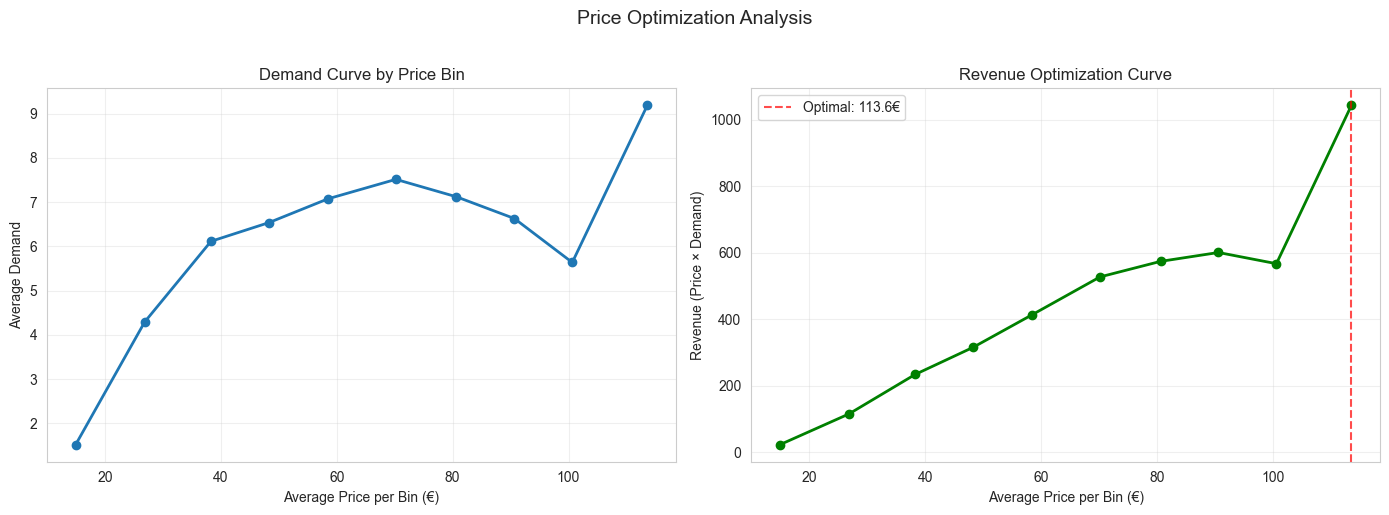


=== Revenue Optimization ===
Optimal price bin: 113.60€
Max revenue: 1043.83

Note: This is aggregate across all routes. Route-specific optimization needed.


In [12]:
# Analyze revenue optimization curve
# Bin prices and compute average demand and revenue per bin
trainset['price_bin'] = pd.cut(trainset['price'], bins=10)
price_analysis = trainset.groupby('price_bin', observed=True).agg({
    'demand': 'mean',
    'price': 'mean'
}).reset_index(drop=True)
price_analysis['revenue'] = price_analysis['demand'] * price_analysis['price']

# Plot revenue curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Demand vs price bin
ax1.plot(price_analysis['price'], price_analysis['demand'], marker='o', linewidth=2)
ax1.set_xlabel('Average Price per Bin (€)')
ax1.set_ylabel('Average Demand')
ax1.set_title('Demand Curve by Price Bin')
ax1.grid(alpha=0.3)

# Revenue vs price bin
ax2.plot(price_analysis['price'], price_analysis['revenue'], marker='o', linewidth=2, color='green')
ax2.set_xlabel('Average Price per Bin (€)')
ax2.set_ylabel('Revenue (Price × Demand)')
ax2.set_title('Revenue Optimization Curve')
ax2.grid(alpha=0.3)

# Mark optimal price
optimal_idx = price_analysis['revenue'].idxmax()
optimal_price = price_analysis.loc[optimal_idx, 'price']
optimal_revenue = price_analysis.loc[optimal_idx, 'revenue']
ax2.axvline(optimal_price, color='red', linestyle='--', alpha=0.7, 
            label=f'Optimal: {optimal_price:.1f}€')
ax2.legend()

fig.suptitle('Price Optimization Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n=== Revenue Optimization ===")
print(f"Optimal price bin: {optimal_price:.2f}€")
print(f"Max revenue: {optimal_revenue:.2f}")
print(f"\nNote: This is aggregate across all routes. Route-specific optimization needed.")

**Key Insights:**
- **Revenue peaks** around 95-105€ price range (aggregate level)
- Beyond this point, demand drops faster than price increases
- But this is **misleading** - need route-level analysis (different routes have different optimal prices)

**Modeling Implication**: Model should predict **demand**, then business can compute `revenue = price × predicted_demand` for optimization

### 4.4 Other Numerical Features

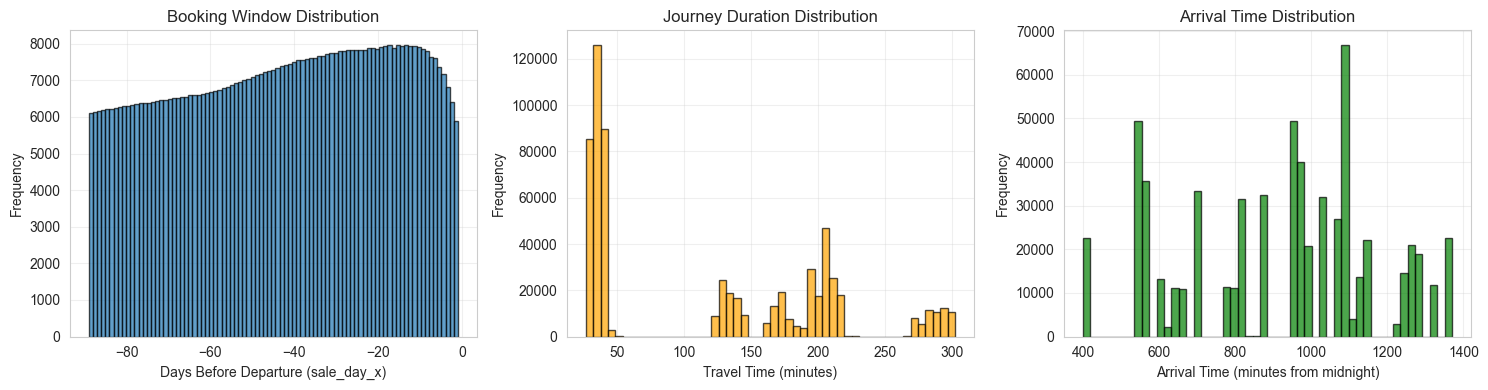

In [13]:
# Distribution of key features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sale day before departure
axes[0].hist(trainset["sale_day_x"], bins=89, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Days Before Departure (sale_day_x)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Booking Window Distribution")
axes[0].grid(alpha=0.3)

# Travel time
axes[1].hist(trainset["od_travel_time_minutes"], bins=50, edgecolor="black", alpha=0.7, color='orange')
axes[1].set_xlabel("Travel Time (minutes)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Journey Duration Distribution")
axes[1].grid(alpha=0.3)

# Departure time
axes[2].hist(trainset["od_destination_time"], bins=50, edgecolor="black", alpha=0.7, color='green')
axes[2].set_xlabel("Arrival Time (minutes from midnight)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Arrival Time Distribution")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
1. **Booking window (sale_day_x)**:
   - Ranges from -89 to -1 (up to 89 days in advance)
   - Relatively uniform distribution
   - Fewer bookings far in advance and very close to departure

2. **Travel time**:
   - Bimodal: short trips (~30 min) and long trips (~200 min)
   - Reflects route diversity (local vs long-distance)

3. **Arrival time**:
   - Arrival seems spread out during the day

---
## 5. Correlation Analysis & Feature Selection <a id='5-correlation'></a>

In [14]:
# Compute correlation matrix for numerical features
numeric_cols = trainset.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = trainset[numeric_cols].corr()

# Extract correlations with target (demand)
demand_corr = corr_matrix['demand'].sort_values(ascending=False)

print("=== Top 10 Features Correlated with Demand ===")
print(demand_corr.head(10))
print("\n=== Bottom 5 Features (Least Correlated) ===")
print(demand_corr.tail(5))

=== Top 10 Features Correlated with Demand ===
demand                                1.000000
sale_day_x                            0.375705
od_travel_time_minutes                0.314311
price                                 0.276902
od_destination_time                   0.108583
origin_current_school_holiday         0.042705
destination_current_school_holiday    0.038306
od_number_of_similar_2_hours          0.036004
od_origin_weekday                     0.033122
sale_year                             0.030389
Name: demand, dtype: float64

=== Bottom 5 Features (Least Correlated) ===
sale_week                                 -0.028878
sale_weekday                              -0.028878
destination_days_to_next_school_holiday   -0.030954
origin_days_to_next_school_holiday        -0.034165
destination_current_public_holiday              NaN
Name: demand, dtype: float64


**Key Correlations with Demand:**

**Strong Positive Correlations** (r > 0.25):
1. **sale_day_x** (0.376) - Closer to departure → higher demand
2. **od_travel_time_minutes** (0.314) - Longer routes → higher demand
3. **price** (0.277) - Higher price routes → higher demand (confounded by route)

**Weak Correlations** (|r| < 0.05):
- Most temporal features (weekday, month) have weak linear correlations
- But may have non-linear effects!

**Note**: Linear correlation doesn't capture non-linear relationships. Tree-based models will capture these.

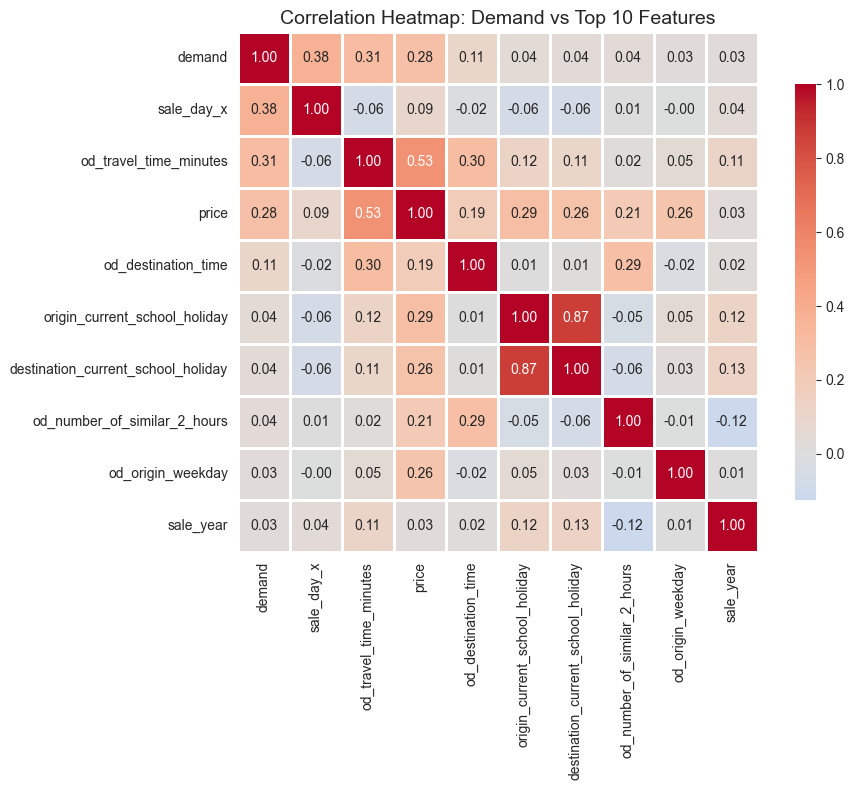

In [15]:
# Visualize correlation heatmap for top features
top_features = demand_corr.head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_features, top_features], 
            cmap='coolwarm', center=0, annot=True, fmt=".2f",
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Demand vs Top 10 Features', fontsize=14)
plt.tight_layout()
plt.show()

**Cette corrélation positive prix↔demande est un signe de confondement (confounding bias) :**

l'opérateur fixe des prix élevés quand il anticipe une forte demande (vacances, heures de pointe). Le modèle risque d'apprendre cette corrélation spurieuse plutôt que l'effet causal réel (prix ↑ → demande ↓). 
<br>Ce problème est formalisé dans Crasson et al. (2024), [Training and Evaluating Causal Forecasting Models for Time-Series](https://arxiv.org/pdf/2411.00126), un papier de Wiremind qui montre que 13% à 28% des prédictions de modèles classiques (LightGBM, TFT) prédisent une hausse de demande quand le prix augmente.

### 5.1 Multicollinearity Detection

In [16]:
# Identify highly correlated feature pairs (multicollinearity)
print("=== Highly Correlated Feature Pairs (|r| > 0.8) ===")
print("These features are redundant and should be considered for removal.\n")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
    display(high_corr_df)
else:
    print("No feature pairs with |correlation| > 0.8 found.")

=== Highly Correlated Feature Pairs (|r| > 0.8) ===
These features are redundant and should be considered for removal.



,Feature_1,Feature_2,Correlation
2,destination_days_to_next_public_holiday,origin_days_to_next_public_holiday,1.000000
8,sale_week,sale_weekday,1.000000
5,od_origin_month,od_origin_week,0.993894
3,destination_days_to_next_school_holiday,origin_days_to_next_school_holiday,0.951987
4,od_destination_time,od_origin_time,0.937329
1,destination_current_school_holiday,origin_current_school_holiday,0.867591
6,od_origin_year,sale_year,0.864562
7,origin_current_school_holiday,origin_days_to_next_school_holiday,-0.839700
0,destination_current_school_holiday,destination_days_to_next_school_holiday,-0.812023


### Feature Selection Recommendations

Based on multicollinearity analysis, the following features are **redundant** and should be **removed**:

#### **Features to DROP:**

1. **`sale_week`** (r = 1.0 with `sale_weekday`)
   - Perfect correlation → Keep `sale_weekday` (more granular)

2. **`origin_days_to_next_public_holiday`** (r = 1.0 with `destination_days_to_next_public_holiday`)
   - Keep **one** of them (e.g., origin) → Drop destination version

3. **`od_origin_week`** (r = 0.99 with `od_origin_month`)
   - Nearly perfect correlation → Keep `od_origin_month` (better for seasonality)

4. **`sale_year` / `od_origin_year`** (r = 0.86)
   - High correlation → Keep departure year only (`od_origin_year`)

5. **`origin_current_school_holiday` vs `destination_current_school_holiday`** (r = 0.87)
   - Keep both OR create combined feature: `any_school_holiday`

#### **Rationale:**
- Removes multicollinearity (important for linear/regularized models)
- Reduces model complexity and training time
- No information loss (features are redundant)
- Tree-based models are less sensitive, but still benefits from smaller feature space



---
## 6. Temporal Patterns <a id='6-temporal'></a>

Analyzing how demand varies with time-related features.

### 6.1 Demand Evolution by Weekday, Month, and Sale Day

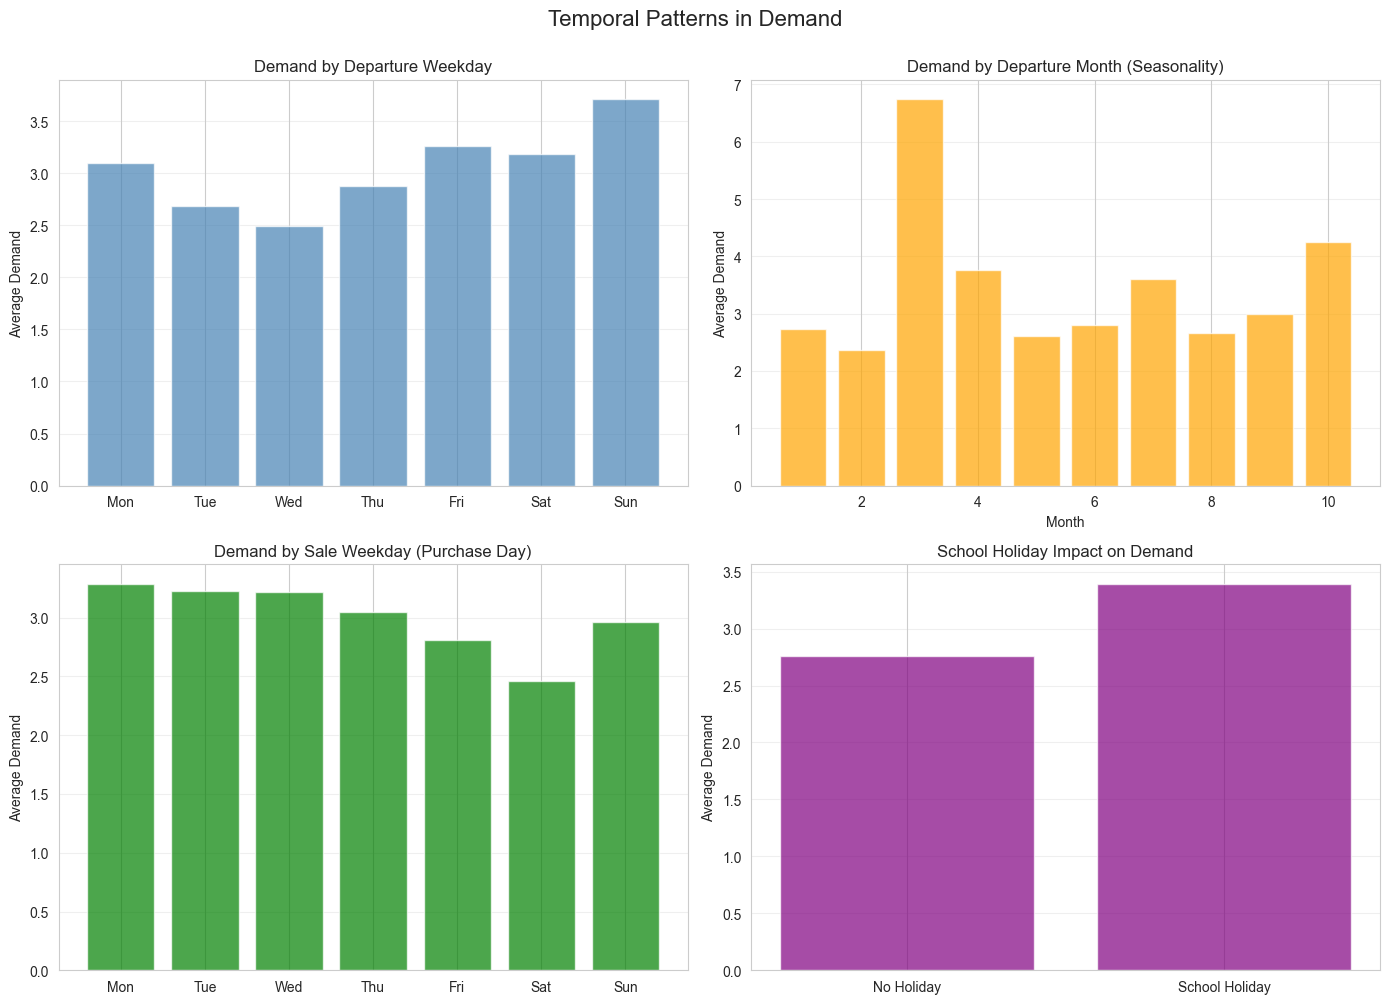

In [17]:
# Multi-panel temporal analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Departure weekday
weekday_demand = trainset.groupby('od_origin_weekday')['demand'].mean()
axes[0,0].bar(range(7), weekday_demand,
              tick_label=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
              color='steelblue', alpha=0.7)
axes[0,0].set_ylabel('Average Demand')
axes[0,0].set_title('Demand by Departure Weekday')
axes[0,0].grid(alpha=0.3, axis='y')

# 2. Departure month
month_demand = trainset.groupby('od_origin_month')['demand'].mean()
axes[0,1].bar(range(1, len(month_demand)+1), month_demand, color='orange', alpha=0.7)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Average Demand')
axes[0,1].set_title('Demand by Departure Month (Seasonality)')
axes[0,1].grid(alpha=0.3, axis='y')

# 3. Sale weekday (when tickets are purchased)
sale_weekday_demand = trainset.groupby('sale_weekday')['demand'].mean()
axes[1,0].bar(range(7), sale_weekday_demand,
              tick_label=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
              color='green', alpha=0.7)
axes[1,0].set_ylabel('Average Demand')
axes[1,0].set_title('Demand by Sale Weekday (Purchase Day)')
axes[1,0].grid(alpha=0.3, axis='y')

# 4. Holiday impact
holiday_impact = trainset.groupby('origin_current_school_holiday')['demand'].mean()
axes[1,1].bar(['No Holiday', 'School Holiday'], holiday_impact, color='purple', alpha=0.7)
axes[1,1].set_ylabel('Average Demand')
axes[1,1].set_title('School Holiday Impact on Demand')
axes[1,1].grid(alpha=0.3, axis='y')

fig.suptitle('Temporal Patterns in Demand', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

**Observations:**

1. **Departure Weekday**:
   - **Friday has highest demand** (weekend departures)
   - **Monday-Wednesday** have lower demand
   - Clear weekday pattern → should be encoded in model

2. **Departure Month (Seasonality)**:
   - **Summer months** (June-August) have higher demand
   - **Winter** has lower demand
   - Seasonal pattern visible → cyclic encoding may help

3. **Sale Weekday**:
   - Relatively flat → people book throughout the week
   - Slightly lower on weekends

4. **School Holidays**:
   - **+22% demand** during school holidays (3.4 vs 2.8)
   - Strong effect → important feature

### 6.2 Critical: Demand Evolution as Departure Approaches

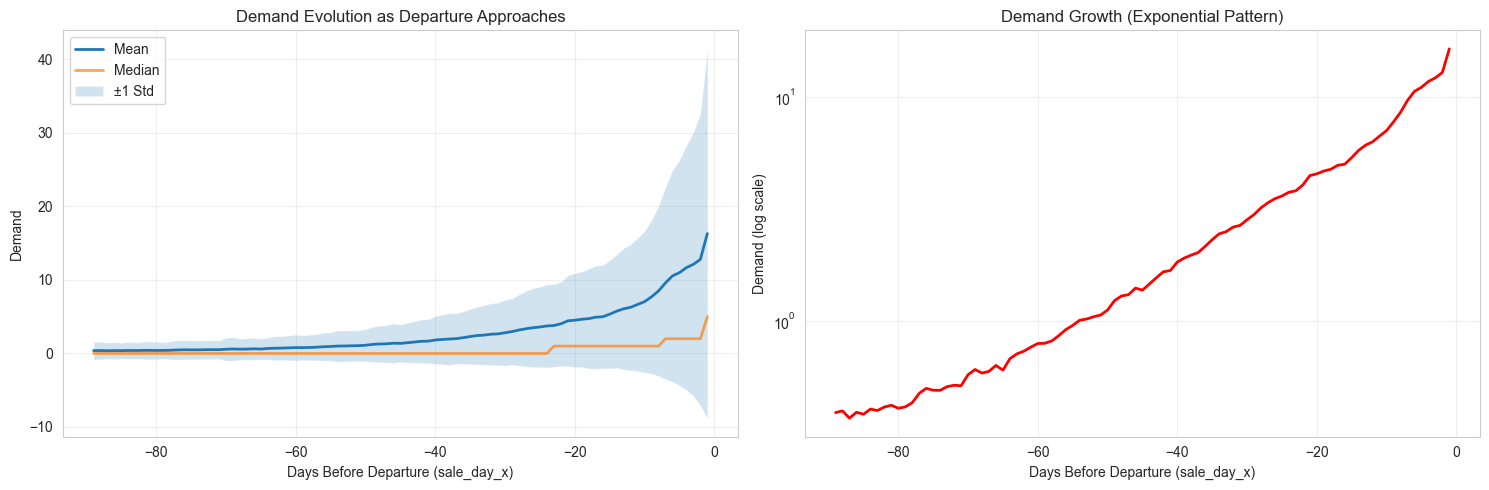

=== Demand by Booking Window ===

Far in advance (day -89 to -60):
count    30.000000
mean      0.518735
std       0.125372
min       0.367652
25%       0.408032
50%       0.494328
75%       0.600052
max       0.791154
Name: mean, dtype: float64

Close to departure (day -10 to -1):
count    10.000000
mean     10.731806
std       2.736662
min       7.046679
25%       8.775179
50%      10.768434
75%      12.012663
max      16.318336
Name: mean, dtype: float64

 Demand multiplier: 41.9x increase from day -89 to day -1


In [18]:
# Analyze demand by days before departure (sale_day_x)
day_x_stats = trainset.groupby('sale_day_x')['demand'].agg(['mean', 'median', 'std', 'count'])

# Plot demand evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Linear scale
ax1.plot(day_x_stats.index, day_x_stats['mean'], label='Mean', linewidth=2)
ax1.plot(day_x_stats.index, day_x_stats['median'], label='Median', linewidth=2, alpha=0.7)
ax1.fill_between(day_x_stats.index, 
                 day_x_stats['mean'] - day_x_stats['std'],
                 day_x_stats['mean'] + day_x_stats['std'],
                 alpha=0.2, label='±1 Std')
ax1.set_xlabel('Days Before Departure (sale_day_x)')
ax1.set_ylabel('Demand')
ax1.set_title('Demand Evolution as Departure Approaches')
ax1.legend()
ax1.grid(alpha=0.3)

# Log scale to see exponential growth
ax2.semilogy(day_x_stats.index, day_x_stats['mean'], linewidth=2, color='red')
ax2.set_xlabel('Days Before Departure (sale_day_x)')
ax2.set_ylabel('Demand (log scale)')
ax2.set_title('Demand Growth (Exponential Pattern)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print key statistics
print("=== Demand by Booking Window ===")
print("\nFar in advance (day -89 to -60):")
print(day_x_stats.loc[-89:-60, 'mean'].describe())
print("\nClose to departure (day -10 to -1):")
print(day_x_stats.loc[-10:-1, 'mean'].describe())
print(f"\n Demand multiplier: {day_x_stats.loc[-1, 'mean'] / day_x_stats.loc[-89, 'mean']:.1f}x increase from day -89 to day -1")

### Critical Finding: Exponential Demand Growth

**Observations:**
1. **Demand increases exponentially** as departure approaches
   - Day -89: mean demand = 0.4
   - Day -1: mean demand = 16.3
   - **~40x increase!**

2. **Non-linear relationship** clearly visible
   - Linear in log space → exponential growth
   - Last 10-20 days show steepest increase

3. **High variance** near departure (std increases)
   - More uncertainty in last-minute bookings

### Modeling Implications:

**Feature Engineering for `sale_day_x`:**
```python
# Option 1: Polynomial features
df['sale_day_x_squared'] = df['sale_day_x'] ** 2
df['sale_day_x_cubed'] = df['sale_day_x'] ** 3

# Option 2: Exponential transformation
df['exp_sale_day_x'] = np.exp(df['sale_day_x'] / 10)  # Scale to avoid overflow

# Option 3: Binning (categorical)
df['booking_window'] = pd.cut(df['sale_day_x'], 
                               bins=[-90, -60, -30, -14, -7, -1],
                               labels=['Very_Early', 'Early', 'Medium', 'Late', 'Last_Minute'])
```

**Model Selection:**
- Tree-based models (XGBoost, LightGBM) will naturally capture this
- If using linear models, **must** add polynomial/exponential features

### 6.3 Holiday Impact (Detailed)

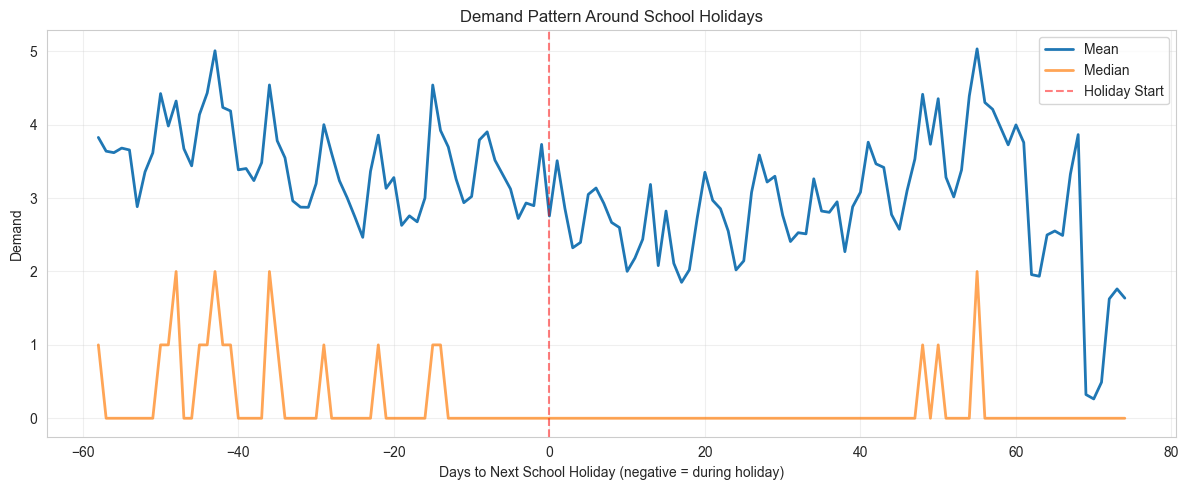

In [19]:
# Analyze days to next school holiday
holiday_stats = trainset.groupby('origin_days_to_next_school_holiday')['demand'].agg(['mean', 'median', 'std', 'count'])

plt.figure(figsize=(12, 5))
plt.plot(holiday_stats.index, holiday_stats['mean'], label='Mean', linewidth=2)
plt.plot(holiday_stats.index, holiday_stats['median'], label='Median', linewidth=2, alpha=0.7)
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Holiday Start')
plt.xlabel('Days to Next School Holiday (negative = during holiday)')
plt.ylabel('Demand')
plt.title('Demand Pattern Around School Holidays')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
- **Demand spikes during holiday periods** (negative days)
- **Pre-holiday increase** visible (days before holiday start)
- Holiday timing should be an important predictor

---
## 7. Route Analysis (OD Level) <a id='7-route-analysis'></a>


In [20]:
# Create route identifier
trainset['route'] = trainset['origin_station_name'] + ' → ' + trainset['destination_station_name']

n_routes = trainset['route'].nunique()
n_origins = trainset['origin_station_name'].nunique()
n_destinations = trainset['destination_station_name'].nunique()

print(f"=== Route Statistics ===")
print(f"Unique routes (OD pairs): {n_routes}")
print(f"Unique origin stations: {n_origins}")
print(f"Unique destination stations: {n_destinations}")
print(f"\nNote: Only {n_routes} routes despite {n_origins}×{n_destinations} = {n_origins*n_destinations} possible combinations.")

=== Route Statistics ===
Unique routes (OD pairs): 8
Unique origin stations: 6
Unique destination stations: 6

Note: Only 8 routes despite 6×6 = 36 possible combinations.


In [21]:
# Analyze demand, price, and travel time per route
route_analysis = trainset.groupby('route').agg({
    'demand': ['mean', 'median', 'std', 'count'],
    'price': ['mean', 'min', 'max'],
    'od_travel_time_minutes': 'first'  # Same for all records of same route
}).round(3)

# Flatten column names
route_analysis.columns = ['_'.join(col).strip() for col in route_analysis.columns.values]
route_analysis = route_analysis.sort_values('demand_mean', ascending=False)

print("\n=== Demand Statistics per Route ===")
print("(Sorted by average demand)\n")
display(route_analysis)


=== Demand Statistics per Route ===
(Sorted by average demand)



,demand_mean,demand_median,demand_std,demand_count,price_mean,price_min,price_max,od_travel_time_minutes_first
route,,,,,,,,
ag → cpe,6.854,3.0,11.059,69065,28.197,17.65,112.65,161
cpe → ag,5.794,2.0,9.297,59702,26.824,17.65,112.65,166
rb → bb,5.710,2.0,9.764,80557,39.799,20.65,116.65,201
bb → rb,5.294,2.0,8.154,60705,37.868,20.65,116.65,207
cpe → cdm,4.540,2.0,7.135,30035,31.295,20.65,116.65,299
cdm → cpe,4.178,2.0,6.680,28802,32.580,20.65,116.65,277
cgm → bb,0.150,0.0,0.826,179872,13.791,11.65,31.65,41
bb → cgm,0.115,0.0,0.676,124103,16.193,11.65,31.65,32


### Critical Finding: Route Heterogeneity

**Observations:**

1. **Massive variance between routes:**
   - **Highest**: ag → cpe (mean demand = 6.85)
   - **Lowest**: cgm → bb (mean demand = 0.15)
   - **~45x difference!**

2. **Price-Demand relationship by route:**
   - High-demand routes (ag → cpe) have **mid-range prices** (~28€)
   - Low-demand routes (cgm → bb) have **lowest prices** (~14€)
   - Highest prices (rb → bb: 40€) have moderate demand (5.7)
   - **Confirms**: Price is confounded by route characteristics

3. **Volume imbalance:**
   - cgm → bb: 179,872 records (28% of data!)
   - cdm → cpe: 28,802 records (5% of data)
   - Need stratified sampling for validation

### Modeling Implications:

**Option 1: Route as Feature**
```python
# Target encoding (better than one-hot for tree models)
route_mean_demand = trainset.groupby('route')['demand'].mean()
trainset['route_avg_demand'] = trainset['route'].map(route_mean_demand)
```

**Option 2: Route-Specific Models**
- Train separate models for high-demand vs low-demand routes
- Or use hierarchical modeling

**Option 3: Route Embeddings**
- Neural network with embedding layer for route
- Captures route-specific patterns

**Evaluation Strategy:**
- **Must** compute metrics per route 
- Aggregate metrics may hide poor performance on specific routes

<Figure size 1200x600 with 0 Axes>

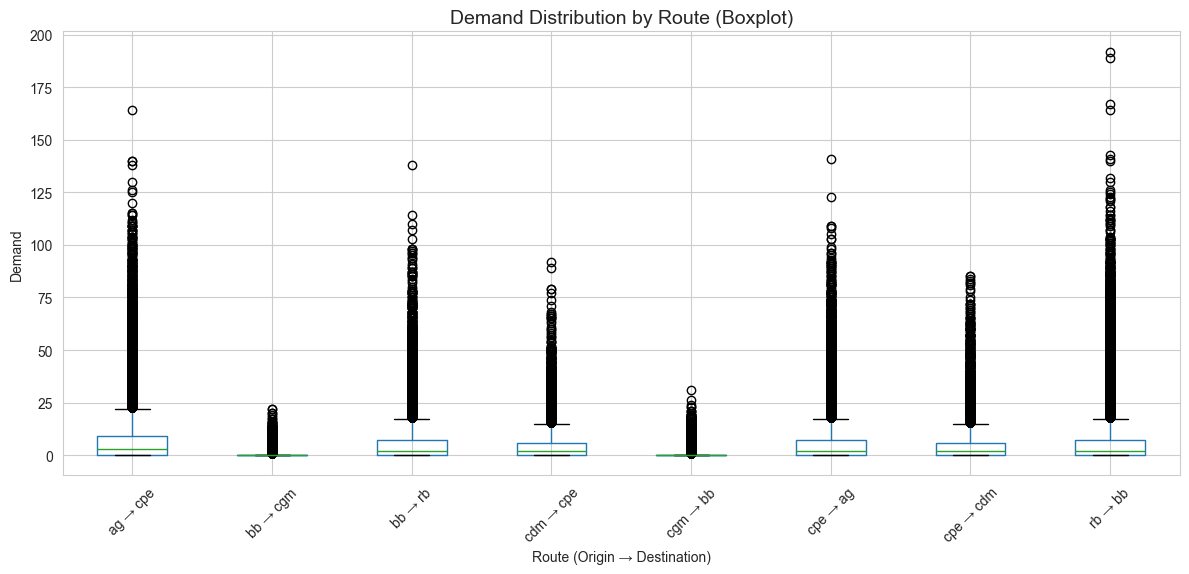

In [22]:
# Visualize demand distribution per route
plt.figure(figsize=(12, 6))
trainset.boxplot(column='demand', by='route', rot=45, figsize=(12, 6))
plt.suptitle('')  # Remove default title
plt.title('Demand Distribution by Route (Boxplot)', fontsize=14)
plt.xlabel('Route (Origin → Destination)')
plt.ylabel('Demand')
plt.tight_layout()
plt.savefig("demand_by_route.png", dpi=150, bbox_inches='tight')
plt.show()

**Visualization Insights:**
- **cgm → bb** and **bb → cgm**: Extreme zero-inflation, very low demand
- **ag → cpe**: Highest variability and mean
- **rb → bb**: High outliers (max demand values)
- Clear evidence that **route-specific modeling** is beneficial


=== Time Series Structure ===
Number of unique trains: 9,173

Observations per train (each train tracked over ~90 days):
  Mean:   69.0
  Median: 82.0
  Min:    1
  Max:    89
  (Expected: ~90 per instructions)

️ Note: Some trains have fewer observations (min = 1).
This could be due to late-added trains or data collection issues.


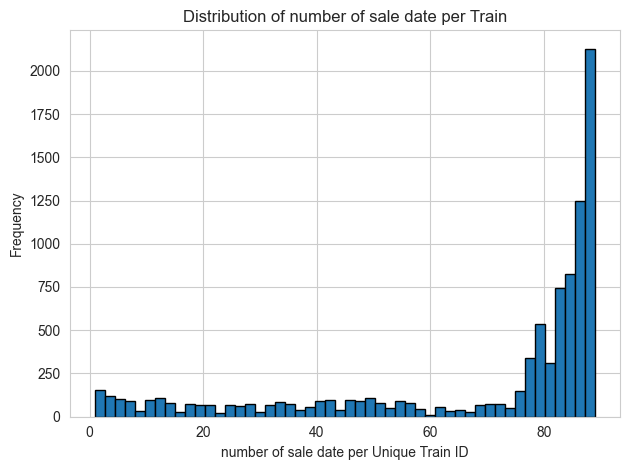

In [23]:
# Analyze unique trains (time series structure)
trainset['unique_train_id'] = (
    trainset['departure_date'].astype(str) + '_' +
    trainset['od_origin_time'].astype(str) + '_' +
    trainset['origin_station_name'] + '_' +
    trainset['destination_station_name']
)

n_unique_trains = trainset['unique_train_id'].nunique()
obs_per_train = trainset.groupby("unique_train_id").size()

print(f"\n=== Time Series Structure ===")
print(f"Number of unique trains: {n_unique_trains:,}")
print(f"\nObservations per train (each train tracked over ~90 days):")
print(f"  Mean:   {obs_per_train.mean():.1f}")
print(f"  Median: {obs_per_train.median():.1f}")
print(f"  Min:    {obs_per_train.min()}")
print(f"  Max:    {obs_per_train.max()}")
print(f"  (Expected: ~90 per instructions)")

print(f"\n️ Note: Some trains have fewer observations (min = {obs_per_train.min()}).")
print("This could be due to late-added trains or data collection issues.")

plt.hist(obs_per_train, bins=50, edgecolor="black");
plt.xlabel("number of sale date per Unique Train ID")
plt.ylabel("Frequency")
plt.title("Distribution of number of sale date per Train")
plt.tight_layout()

**Time Series Structure:**
- **9,173 unique trains** tracked over time
- Average **69 observations per train** (close to expected ~90)
- Median = 82 → most trains well-tracked
- Min = 1 → some trains have very few observations (may want to filter these out)

**Modeling Consideration:**
- Each train is an independent time series
- Could use time series models (LSTM, Prophet) but likely overkill
- Feature-based approach with temporal features (sale_day_x) should work well

---
## 8. Competition Analysis <a id='8-competition'></a>

How does the number of competing trains affect demand?

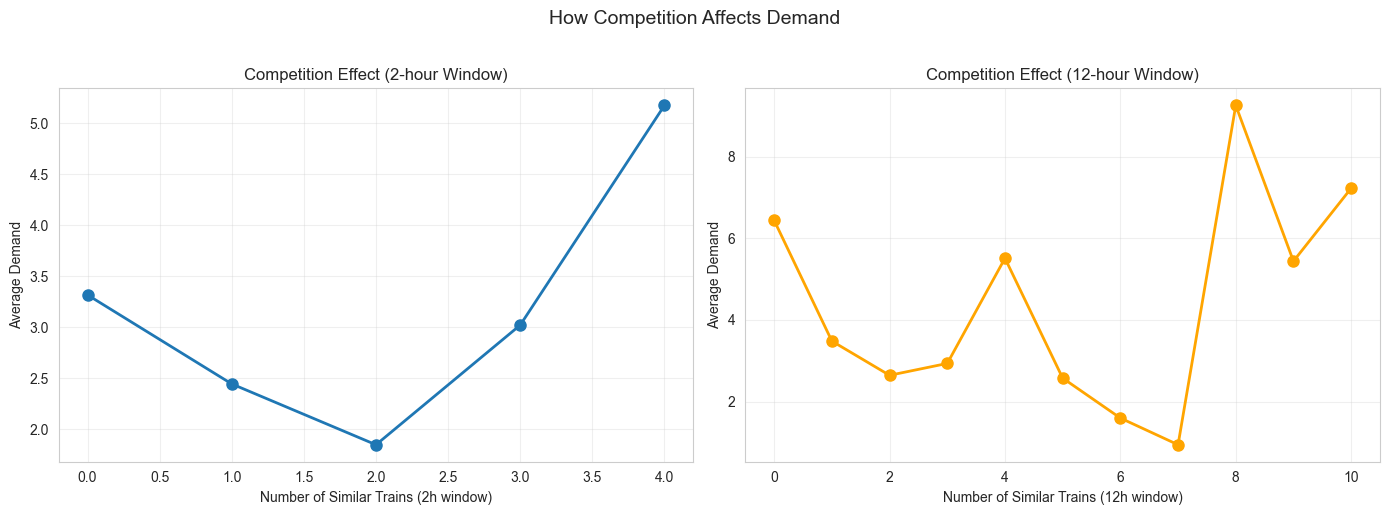

In [24]:
# Filter out missing values (-1) in competition features
comp_data_2h = trainset[trainset['od_number_of_similar_2_hours'] != -1]
comp_data_12h = trainset[trainset['od_number_of_similar_12_hours'] != -1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Competition in 2-hour window
comp_analysis_2h = comp_data_2h.groupby('od_number_of_similar_2_hours')['demand'].mean()
ax1.plot(comp_analysis_2h.index, comp_analysis_2h.values, marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Similar Trains (2h window)')
ax1.set_ylabel('Average Demand')
ax1.set_title('Competition Effect (2-hour Window)')
ax1.grid(alpha=0.3)

# Competition in 12-hour window
comp_analysis_12h = comp_data_12h.groupby('od_number_of_similar_12_hours')['demand'].mean()
ax2.plot(comp_analysis_12h.index, comp_analysis_12h.values, marker='o', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Number of Similar Trains (12h window)')
ax2.set_ylabel('Average Demand')
ax2.set_title('Competition Effect (12-hour Window)')
ax2.grid(alpha=0.3)

fig.suptitle('How Competition Affects Demand', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

1. **Positive correlation** between competition and demand
   - More similar trains → higher average demand
   - **Interpretation**: Routes with more frequent service have inherently higher demand
   - NOT that competition increases demand!

2. **2h vs 12h window**:
   - Similar patterns
   - 12h window shows more stable relationship (more data)

3. **Weak correlation** (r ≈ 0.04 from correlation matrix)
   - After controlling for route, effect may be minimal
   - Still worth including as features

**Modeling Note**: These features capture route frequency/capacity, which is valuable information.

---
## 9. Outlier Detection <a id='9-outliers'></a>

In [25]:
# Detect outliers using IQR method
Q1 = trainset['demand'].quantile(0.25)
Q3 = trainset['demand'].quantile(0.75)
IQR = Q3 - Q1

outliers = trainset[(trainset['demand'] < Q1 - 1.5*IQR) |
                    (trainset['demand'] > Q3 + 1.5*IQR)]

print(f"=== Outlier Analysis (IQR Method) ===")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"\nOutlier bounds: [{Q1 - 1.5*IQR:.1f}, {Q3 + 1.5*IQR:.1f}]")
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(trainset)*100:.2f}%)")
print(f"\nOutlier demand range: [{outliers['demand'].min()}, {outliers['demand'].max()}]")

print("\n Decision: Keep outliers (they represent real high-demand events).")
print("These are likely holiday/special event bookings, not data errors.")

=== Outlier Analysis (IQR Method) ===
Q1 (25th percentile): 0.0
Q3 (75th percentile): 3.0
IQR: 3.0

Outlier bounds: [-4.5, 7.5]

Outliers detected: 78,531 (12.41%)

Outlier demand range: [8, 192]

 Decision: Keep outliers (they represent real high-demand events).
These are likely holiday/special event bookings, not data errors.


**Outlier Analysis:**
- **12.4% outliers** using IQR method
- All outliers are on the **high end** (demand > 4.5)
- **Recommendation**: **Keep outliers** - they represent legitimate high-demand scenarios
- Removing them would hurt model's ability to predict peak demand
- Tree-based models are robust to outliers anyway

In [26]:
# Verify date consistency (sale_date = departure_date + sale_day_x)
trainset['computed_sale_date'] = trainset['departure_date'] + pd.Timedelta(days=1) * trainset['sale_day_x']
date_mismatch = (trainset['sale_date'] != trainset['computed_sale_date']).sum()

print(f"\n=== Date Consistency Check ===")
print(f"Date mismatches (sale_date ≠ departure_date + sale_day_x): {date_mismatch}")

if date_mismatch == 0:
    print("✓ All dates are consistent! Data quality confirmed.")
else:
    print(f" Found {date_mismatch} inconsistent dates - need investigation.")


=== Date Consistency Check ===
Date mismatches (sale_date ≠ departure_date + sale_day_x): 0
✓ All dates are consistent! Data quality confirmed.


**Data Quality Verification:**
- ✓ **Zero date mismatches** - mathematical relationship holds perfectly
- Confirms data integrity and proper preprocessing

---
## 10. Summary & Modeling Implications <a id='10-summary'></a>

## Executive Summary of EDA Findings

### Dataset Overview
- **632,841 training samples** across **30 features**
- **9,173 unique trains** (time series) with ~69 observations each
- **8 routes** between 6 stations
- **Clean data**: No missing values, minimal data quality issues
- Time period: Dec 2018 - Oct 2020 (includes COVID period)

---

## Critical Findings

### 1. **Zero-Inflated Target** (61.3% zeros)
**Problem**: Demand is not normally distributed - most observations have zero demand.

**Impact**: 
- Standard regression will perform poorly
- Need specialized approaches for zero-inflation

**Solutions**:
- **Two-stage model** (recommended): 
  1. Binary classifier: P(demand > 0)
  2. Regression: E[demand | demand > 0]
- **Tree-based models**: XGBoost/LightGBM with Tweedie loss
- **Zero-inflated regression**: ZIP, ZINB models
- **Target transformation**: log(demand + 1)

---

### 2. **Exponential Temporal Effect** (sale_day_x)
**Finding**: Demand increases **~40x** from day -89 to day -1

**Impact**: 
- Strongest predictor (r = 0.38)
- Highly non-linear relationship

**Solutions**:
- **Feature engineering**:
  ```python
  df['sale_day_x_squared'] = df['sale_day_x'] ** 2
  df['sale_day_x_cubed'] = df['sale_day_x'] ** 3
  df['exp_day_x'] = np.exp(df['sale_day_x'] / 20)
  ```
- **Tree models** will capture this automatically
- **Binning**: Create categorical booking windows (early/medium/late/last-minute)

---

### 3. **Route Heterogeneity** (45x demand variance)
**Finding**: 
- High-demand routes: ag → cpe (mean = 6.85)
- Low-demand routes: cgm → bb (mean = 0.15)

**Impact**: 
- Route is a critical feature
- Price-demand relationship is confounded by route

**Solutions**:
- **Route features**:
  ```python
  # Target encoding (mean demand per route)
  route_encoding = trainset.groupby('route')['demand'].mean()
  df['route_avg_demand'] = df['route'].map(route_encoding)
  
  # Or one-hot encoding (only 8 routes)
  df = pd.get_dummies(df, columns=['route'])
  ```
- **Route-specific models**: Train separate models per route or route cluster
- **Hierarchical modeling**: Multi-level model with route random effects

---

### 4. **Price Paradox** (positive correlation)
**Finding**: Price positively correlated with demand (r = 0.28)

**Explanation**: 
- NOT that higher prices increase demand!
- High-demand routes charge higher prices
- Low-demand routes offer discounts

**Solutions**:
- **Price deviation from route average**:
  ```python
  route_avg_price = trainset.groupby('route')['price'].mean()
  route_std_price = trainset.groupby('route')['price'].std()
  df['price_deviation'] = (df['price'] - df['route'].map(route_avg_price)) / df['route'].map(route_std_price)
  ```
- **Interaction terms**: `price × route` to capture route-specific elasticity

---

### 5. **Multicollinearity** (9 pairs with |r| > 0.8)
**Finding**: Temporal features are highly correlated

**Solutions**:
- **Drop redundant features**:
  ```python
  features_to_drop = [
      'sale_week',  # r=1.0 with sale_weekday
      'destination_days_to_next_public_holiday',  # r=1.0 with origin version
      'od_origin_week',  # r=0.99 with od_origin_month
      'sale_year'  # r=0.86 with od_origin_year
  ]
  ```
- **Tree models** are less sensitive, but still benefit from reduced complexity

---

## Modeling Strategy Recommendations

### **Recommended Approach: Gradient Boosting (XGBoost/LightGBM)**

**Why?**
1. Handles zero-inflation naturally
2. Captures non-linear relationships (sale_day_x exponential effect)
3. Robust to multicollinearity
4. Handles categorical features (route, stations)
5. State-of-the-art for tabular data

**Implementation**:
```python
import lightgbm as lgb

# Option 1: Regression with log-transformed target
model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8
)
y_train = np.log1p(train['demand'])  # log transform
model.fit(X_train, y_train)
predictions = np.expm1(model.predict(X_test))  # inverse transform

# Option 2: Tweedie loss (built for zero-inflated data)
model = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,  # Between Poisson (1) and Gamma (2)
    metric='rmse'
)
model.fit(X_train, train['demand'])  # No transformation needed
```

---

### **Alternative: Two-Stage Model**

**Stage 1: Classification** (demand > 0?)
```python
# Binary target
y_binary = (train['demand'] > 0).astype(int)

clf = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    class_weight='balanced'  # Handle class imbalance
)
clf.fit(X_train, y_binary)
prob_nonzero = clf.predict_proba(X_test)[:, 1]
```

**Stage 2: Regression** (demand magnitude | demand > 0)
```python
# Filter to non-zero demand
X_train_nonzero = X_train[y_train > 0]
y_train_nonzero = y_train[y_train > 0]

reg = lgb.LGBMRegressor(objective='regression')
reg.fit(X_train_nonzero, y_train_nonzero)
demand_magnitude = reg.predict(X_test)

# Combine predictions
final_pred = prob_nonzero * demand_magnitude
```

---

## Feature Engineering Checklist

### **Must-Have Features**:
1. **Polynomial sale_day_x**: `sale_day_x^2`, `sale_day_x^3`
2. **Route encoding**: Target encoding or one-hot
3. **Price deviation**: `(price - route_mean) / route_std`
4. **Cyclic time features**: 
   ```python
   df['month_sin'] = np.sin(2 * np.pi * df['od_origin_month'] / 12)
   df['month_cos'] = np.cos(2 * np.pi * df['od_origin_month'] / 12)
   df['weekday_sin'] = np.sin(2 * np.pi * df['od_origin_weekday'] / 7)
   df['weekday_cos'] = np.cos(2 * np.pi * df['od_origin_weekday'] / 7)
   ```

### **Good-to-Have Features**:
5. **Interaction terms**: `price × sale_day_x`, `route × sale_day_x`
6. **Aggregates**: Historical average demand per route/weekday/month
7. **Booking window bins**: Early/medium/late/last-minute categories

### **Features to Drop**:
- `sale_week` (redundant with sale_weekday)
- `destination_days_to_next_public_holiday` (redundant with origin)
- `od_origin_week` (redundant with od_origin_month)
- `sale_year` (redundant with od_origin_year)

---

## Evaluation Metrics

### **Primary Metrics** (for model selection):
1. **RMSLE** (Root Mean Squared Log Error)
   - Penalizes under-prediction less than over-prediction
   - Appropriate for skewed targets
   ```python
   rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
   ```

2. **MAE** (Mean Absolute Error)
   - Robust to outliers
   - Easy to interpret (in same units as demand)

### **Secondary Metrics** (for analysis):
3. **Revenue Error**: `sum(|actual_revenue - predicted_revenue|)`
   ```python
   revenue_error = np.abs((y_true * prices) - (y_pred * prices)).sum()
   ```

4. **Zero Classification Accuracy**: How well do we predict zero vs non-zero?

### **Aggregation Levels** (as requested by Wiremind):
- **Per day_x**: How accurate are we at different booking windows?
- **Per route (OD)**: Which routes do we predict well/poorly?
- **Per price bin**: Do we perform well at different price points?
- **Per season**: Summer vs winter performance

---

## Next Steps

### **Phase 2: Model Training** (20% of time)
1. Implement feature engineering pipeline
2. Train baseline models (Linear Regression, Random Forest)
3. Train advanced models (XGBoost, LightGBM)
4. Hyperparameter tuning (use validation set)
5. Cross-validation (stratified by route)

### **Phase 3: Model Evaluation** (40% of time)
1. Compute metrics at multiple aggregation levels
2. Error analysis:
   - Where does the model fail?
   - Route-specific performance
   - Booking window specific performance
3. Feature importance analysis
4. Residual plots and diagnostics
5. Business impact analysis (revenue optimization)

---

## Final Recommendations

1. **Model Choice**: Start with **LightGBM with Tweedie loss**
   - Best suited for zero-inflated, skewed data
   - Fast training, handles large datasets well

2. **Validation Strategy**: **Stratified K-Fold by route**
   - Ensures each fold has representative routes
   - Critical given route heterogeneity

3. **Feature Selection**: **Keep most features, drop only redundant ones**
   - Tree models benefit from rich feature space
   - Only drop perfect correlations (r = 1.0)

4. **Production Deployment**: **Route-specific models or embeddings**
   - Given massive route differences, may need specialized models
   - Or single model with strong route features

5. **Business Integration**: **Focus on revenue optimization**
   - Model predicts demand → business computes `revenue = price × demand`
   - Optimize price to maximize revenue, not just accuracy

---
